# Fresher Hiring India Dataset Analysis
This notebook performs a full exploratory data analysis and a machine learning classification workflow on the `fresher_hiring_india_dataset.csv` dataset. We will inspect the data, clean it, derive features, and build a model to predict whether a candidate receives a job offer.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
file_path = r"c:\Users\Sarvagya\Desktop\Codes\Projects\Machine Learning and Deep Learning Notebooks\fresher_hiring_india_dataset.csv"
df = pd.read_csv(file_path)

# Show the first rows of the dataset
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 30)


,candidate_id,full_name,gender,age,graduation_year,college,degree,branch,cgpa,backlogs,...,job_location,application_date,hiring_stage,interview_rounds,response_time_days,offered_salary_inr,linkedin_connections,profile_completion_pct,linkedin_premium,referral_applied
0,1,Deepika Shukla,Female,23,2021,BITS Goa,B.E.,Electrical,5.89,3,...,Bengaluru,2021-11-23,Technical Interview,3.0,22,NaN,1188,64,NaN,No
1,2,Piyush Reddy,Male,25,2022,IIEST Shibpur,B.Sc (IT),Information Technology,8.78,0,...,Ahmedabad,2021-07-26,Shortlisted,NaN,30,NaN,2653,78,Yes,No
2,3,Itisha Arora,Female,21,2024,BIT Mesra Ranchi,BCA,Computer Applications,6.24,3,...,Delhi NCR,2022-03-09,Rejected,4.0,37,NaN,2990,75,NaN,No
3,4,Darshan Dey,Male,22,2022,BITS Goa,B.Sc (CS),Computer Science,8.86,3,...,Coimbatore,2023-08-17,Online Assessment,NaN,36,NaN,97,98,No,No
4,5,Uma Grewal,Female,25,2020,Pune University,MCA,Computer Applications,7.54,2,...,Bengaluru,2024-05-11,Shortlisted,NaN,2,NaN,508,78,No,No


In [2]:
# Basic overview of columns and data types
print(df.info())
print("\nMissing values by column:\n", df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   candidate_id            5000 non-null   int64  
 1   full_name               5000 non-null   str    
 2   gender                  5000 non-null   str    
 3   age                     5000 non-null   int64  
 4   graduation_year         5000 non-null   int64  
 5   college                 5000 non-null   str    
 6   degree                  5000 non-null   str    
 7   branch                  5000 non-null   str    
 8   cgpa                    5000 non-null   float64
 9   backlogs                5000 non-null   int64  
 10  gap_year                5000 non-null   str    
 11  prior_internship        5000 non-null   str    
 12  projects_count          5000 non-null   int64  
 13  certifications_count    5000 non-null   int64  
 14  top_skills              5000 non-null   str    
 15

## Data Cleaning and Feature Engineering
We will clean the dataset by converting columns to the correct types, handling missing values, and creating a binary target column for whether the candidate received an offer.

In [3]:
# Clean and transform columns
clean_df = df.copy()
clean_df["cgpa"] = pd.to_numeric(clean_df["cgpa"], errors="coerce")
clean_df["backlogs"] = pd.to_numeric(clean_df["backlogs"], errors="coerce")
clean_df["projects_count"] = pd.to_numeric(clean_df["projects_count"], errors="coerce")
clean_df["certifications_count"] = pd.to_numeric(clean_df["certifications_count"], errors="coerce")
clean_df["linkedin_connections"] = pd.to_numeric(clean_df["linkedin_connections"], errors="coerce")
clean_df["profile_completion_pct"] = pd.to_numeric(clean_df["profile_completion_pct"], errors="coerce")
clean_df["response_time_days"] = pd.to_numeric(clean_df["response_time_days"], errors="coerce")
clean_df["offered_salary_inr"] = pd.to_numeric(clean_df["offered_salary_inr"], errors="coerce")

clean_df["application_date"] = pd.to_datetime(clean_df["application_date"], errors="coerce")
clean_df["gap_year"] = clean_df["gap_year"].replace({"Yes": 1, "No": 0})

# Create a binary target: candidate received an offer or not
clean_df["offer_received"] = np.where(clean_df["hiring_stage"].str.strip().str.lower() == "offer", 1, 0)

# Preview cleaning results
clean_df.head()

,candidate_id,full_name,gender,age,graduation_year,college,degree,branch,cgpa,backlogs,...,application_date,hiring_stage,interview_rounds,response_time_days,offered_salary_inr,linkedin_connections,profile_completion_pct,linkedin_premium,referral_applied,offer_received
0,1,Deepika Shukla,Female,23,2021,BITS Goa,B.E.,Electrical,5.89,3,...,2021-11-23,Technical Interview,3.0,22,NaN,1188,64,NaN,No,0
1,2,Piyush Reddy,Male,25,2022,IIEST Shibpur,B.Sc (IT),Information Technology,8.78,0,...,2021-07-26,Shortlisted,NaN,30,NaN,2653,78,Yes,No,0
2,3,Itisha Arora,Female,21,2024,BIT Mesra Ranchi,BCA,Computer Applications,6.24,3,...,2022-03-09,Rejected,4.0,37,NaN,2990,75,NaN,No,0
3,4,Darshan Dey,Male,22,2022,BITS Goa,B.Sc (CS),Computer Science,8.86,3,...,2023-08-17,Online Assessment,NaN,36,NaN,97,98,No,No,0
4,5,Uma Grewal,Female,25,2020,Pune University,MCA,Computer Applications,7.54,2,...,2024-05-11,Shortlisted,NaN,2,NaN,508,78,No,No,0


In [4]:
# Check the target distribution
print(clean_df["offer_received"].value_counts())
print("Offer rate: {:.2f}%".format(clean_df["offer_received"].mean() * 100))

offer_received
0    4378
1     622
Name: count, dtype: int64
Offer rate: 12.44%


## Exploratory Data Analysis (EDA)
We'll explore numeric distributions, categorical relationships, and how the offer rate varies across key features.

In [5]:
# Numeric feature distributions
numeric_cols = ["age", "cgpa", "backlogs", "projects_count", "certifications_count", "response_time_days", "offered_salary_inr", "linkedin_connections", "profile_completion_pct"]
clean_df[numeric_cols].describe()

,age,cgpa,backlogs,projects_count,certifications_count,response_time_days,offered_salary_inr,linkedin_connections,profile_completion_pct
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,6.220000e+02,5000.000000,5000.000000
mean,23.501800,7.742102,1.500200,2.998000,2.49780,23.244600,4.916031e+05,1522.969200,77.446600
std,2.293262,1.304093,1.119397,1.999699,1.70299,13.013418,3.911957e+05,854.079153,13.177567
min,20.000000,5.500000,0.000000,0.000000,0.00000,1.000000,8.098000e+03,50.000000,55.000000
25%,21.000000,6.620000,0.000000,1.000000,1.00000,12.000000,3.646150e+04,782.750000,66.000000
50%,24.000000,7.730000,1.000000,3.000000,2.00000,24.000000,4.900845e+05,1515.000000,78.000000
75%,26.000000,8.890000,3.000000,5.000000,4.00000,35.000000,7.295302e+05,2276.000000,89.000000
max,27.000000,10.000000,3.000000,6.000000,5.00000,45.000000,1.925970e+06,3000.000000,100.000000


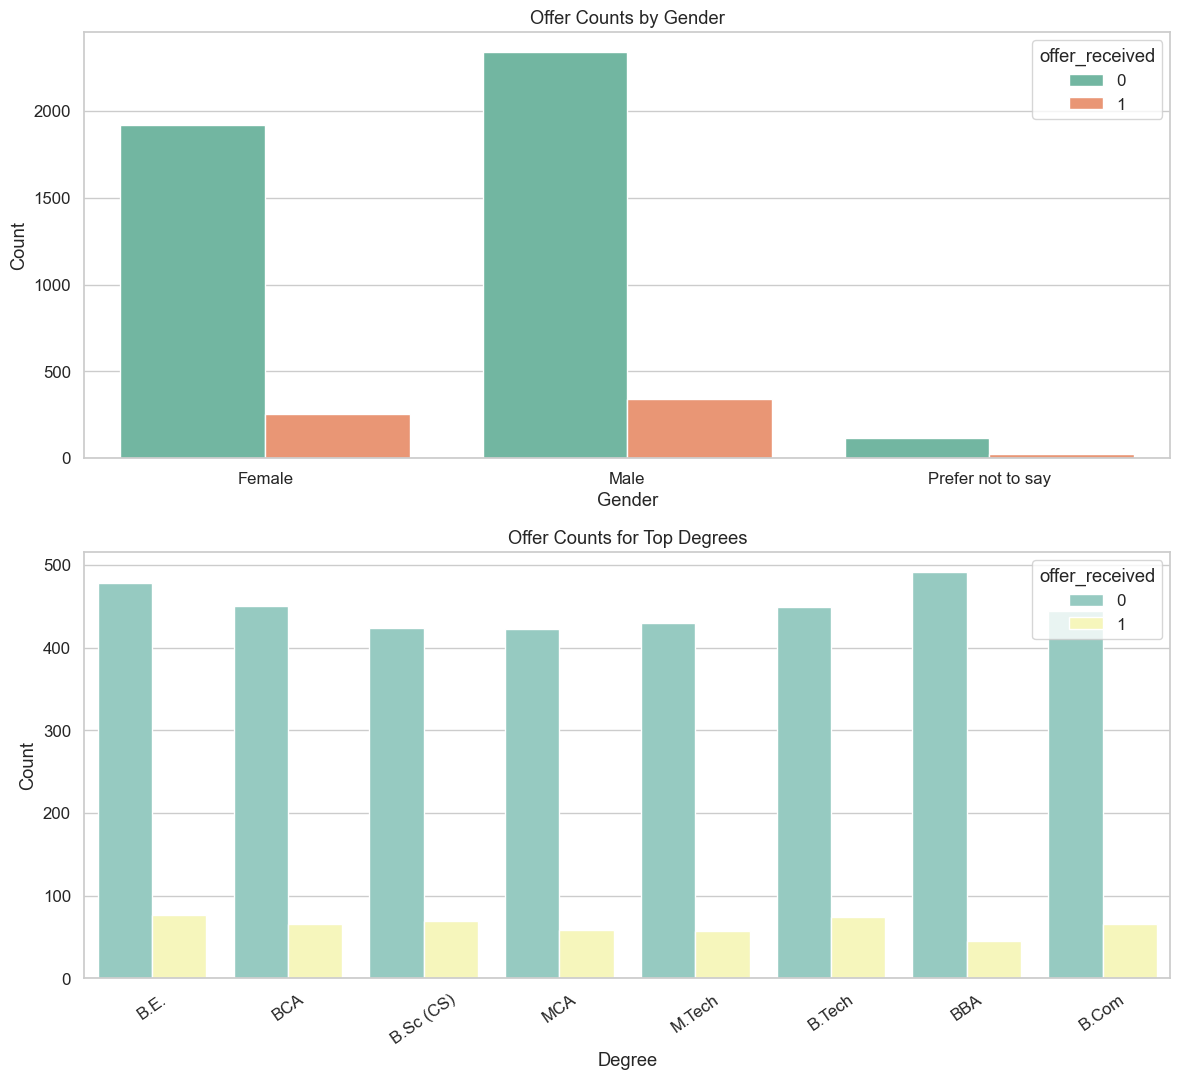

In [6]:
# Plot offer rate by gender and education branch
fig, axes = plt.subplots(2, 1, figsize=(12, 11))

sns.countplot(data=clean_df, x="gender", hue="offer_received", palette="Set2", ax=axes[0])
axes[0].set_title("Offer Counts by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

# Show top 8 degree categories by count and offer rate
top_degrees = clean_df["degree"].value_counts().nlargest(8).index
sns.countplot(data=clean_df[clean_df["degree"].isin(top_degrees)], x="degree", hue="offer_received", palette="Set3", ax=axes[1])
axes[1].set_title("Offer Counts for Top Degrees")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

In [7]:
# Offer rate by college and sector
offer_rate_by_college = clean_df.groupby("college")["offer_received"].mean().sort_values(ascending=False).head(10)
offer_rate_by_sector = clean_df.groupby("sector")["offer_received"].mean().sort_values(ascending=False).head(10)
print("Top 10 Colleges by Offer Rate:\n", offer_rate_by_college)
print("\nTop 10 Sectors by Offer Rate:\n", offer_rate_by_sector)

Top 10 Colleges by Offer Rate:
 college
COEP Pune                          0.222222
Osmania University Hyderabad       0.197802
Lovely Professional University     0.189474
Nirma University Ahmedabad         0.183908
Christ University Bangalore        0.180723
Delhi University                   0.178218
Symbiosis Pune                     0.172043
Manipal Institute of Technology    0.155556
GLA University Mathura             0.152941
PES University Bangalore           0.151899
Name: offer_received, dtype: float64

Top 10 Sectors by Offer Rate:
 sector
Logistics                0.142857
Manufacturing            0.140000
IT/Software              0.139818
EdTech                   0.137255
HealthTech               0.132394
Banking & Finance        0.130435
Automotive               0.128205
Media & Entertainment    0.121884
Retail                   0.120448
E-commerce               0.119792
Name: offer_received, dtype: float64


Top 20 skills in the dataset:
 Linux              421
MATLAB             405
REST APIs          391
JavaScript         390
Azure              390
Deep Learning      388
R                  387
Flutter            384
Communication      384
Scala              384
Kubernetes         381
Spring Boot        378
Hadoop             377
Tableau            374
Data Analysis      373
Git                369
Python             366
MongoDB            365
Problem Solving    365
Excel              364
Name: count, dtype: int64


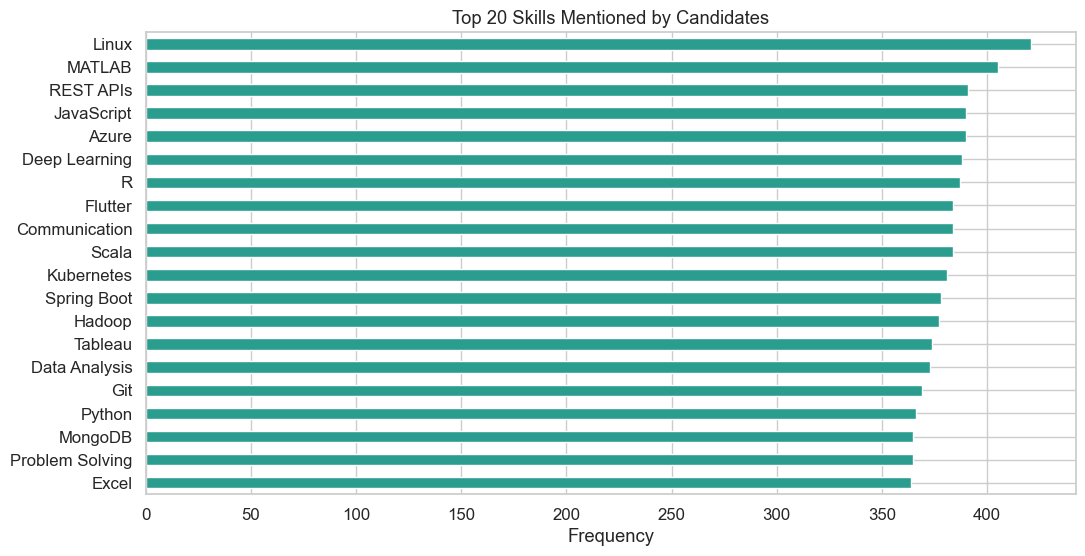

In [8]:
# Top skills exploration
skill_series = clean_df["top_skills"].dropna().str.split("|", expand=True)
skills = skill_series.stack().str.strip().value_counts().nlargest(20)
print("Top 20 skills in the dataset:\n", skills)

plt.figure(figsize=(12, 6))
skills.plot(kind="barh", color="#2a9d8f")
plt.gca().invert_yaxis()
plt.title("Top 20 Skills Mentioned by Candidates")
plt.xlabel("Frequency")
plt.show()

## Modeling Strategy
We'll build a classification model to predict whether a candidate receives an offer. We will use feature transformations and compare logistic regression with a random forest classifier.

In [10]:
# Select features for modeling
features = [
    "gender",
    "age",
    "graduation_year",
    "degree",
    "branch",
    "cgpa",
    "backlogs",
    "gap_year",
    "prior_internship",
    "projects_count",
    "certifications_count",
    "platform",
    "sector",
    "job_role",
    "work_type",
    "job_location",
    "response_time_days",
    "linkedin_connections",
    "profile_completion_pct",
    "linkedin_premium",
    "referral_applied",
]

model_df = clean_df[features + ["offer_received"]].copy()

# Drop rows where the target is missing or invalid
model_df = model_df.dropna(subset=["offer_received"])
model_df.shape

(5000, 22)

In [19]:
# Clean and encode columns before training
model_df["prior_internship"] = model_df["prior_internship"].replace({"Yes": 1, "No": 0})
model_df["linkedin_premium"] = model_df["linkedin_premium"].replace({"Yes": 1, "No": 0, "N/A": 0})
model_df["referral_applied"] = model_df["referral_applied"].replace({"Yes": 1, "No": 0})

# Convert categorical features to string to avoid mixed-type encoding issues
cat_features = ["gender", "degree", "branch", "prior_internship", "platform", "sector", "job_role", "work_type", "job_location", "linkedin_premium", "referral_applied"]
model_df[cat_features] = model_df[cat_features].fillna("missing").astype(str)

# Split data into training and test sets
X = model_df.drop(columns=["offer_received"])
y = model_df["offer_received"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.22, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (3900, 21)
Test set shape: (1100, 21)


In [16]:
# Diagnostic: inspect categorical dtypes and sample values
cat_dtypes = X_train[cat_features].dtypes
sample_values = X_train[cat_features].head(2)
print("Categorical dtypes:\n", cat_dtypes.to_string())
print("\nSample categorical values (first 2 rows):\n", sample_values.to_dict(orient="list"))

# Diagnostic only: no pipeline fit in this cell


Categorical dtypes:
 gender                 str
degree                 str
branch                 str
prior_internship    object
platform               str
sector                 str
job_role               str
work_type              str
job_location           str
linkedin_premium    object
referral_applied    object

Sample categorical values (first 2 rows):
 {'gender': ['Female', 'Female'], 'degree': ['M.Tech', 'MBA'], 'branch': ['Computer Science', 'Marketing'], 'prior_internship': [1, 1], 'platform': ['LinkedIn', 'Naukri'], 'sector': ['Retail', 'Retail'], 'job_role': ['HR Executive', 'SEO Analyst'], 'work_type': ['Contract', 'Contract'], 'job_location': ['Kolkata', 'Lucknow'], 'linkedin_premium': [0, nan], 'referral_applied': [0, 0]}


In [20]:
# Build preprocessing pipeline
numeric_features = ["age", "graduation_year", "cgpa", "backlogs", "gap_year", "projects_count", "certifications_count", "response_time_days", "linkedin_connections", "profile_completion_pct"]
cat_features = ["gender", "degree", "branch", "prior_internship", "platform", "sector", "job_role", "work_type", "job_location", "linkedin_premium", "referral_applied"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, cat_features),
])

# Use a Random Forest classifier in a full pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Accuracy: 0.8754545454545455
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.93       963
           1       0.00      0.00      0.00       137

    accuracy                           0.88      1100
   macro avg       0.44      0.50      0.47      1100
weighted avg       0.77      0.88      0.82      1100



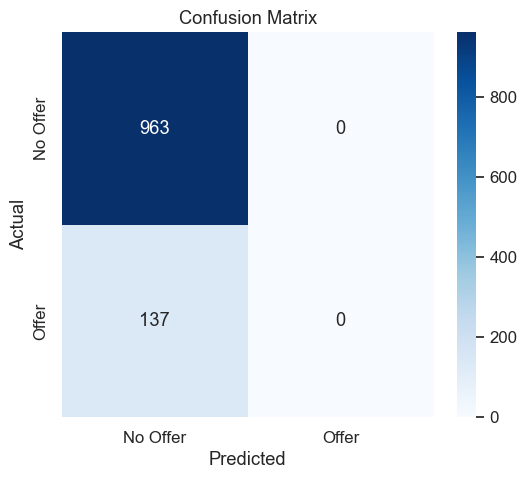

In [21]:
# Evaluate the random forest model
y_pred = rf_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Offer", "Offer"], yticklabels=["No Offer", "Offer"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_28200\2508200690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x="importance", y="feature", palette="viridis")


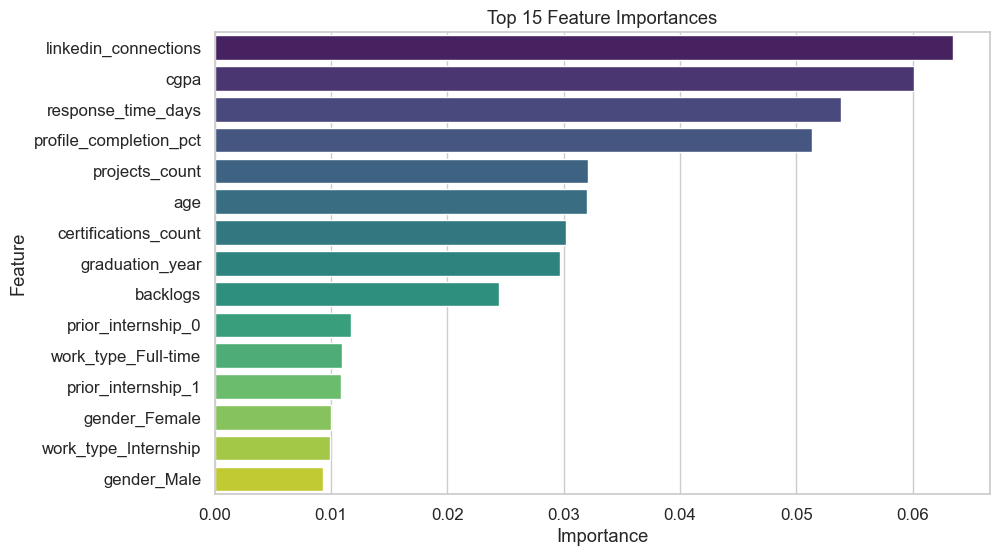

In [22]:
# Feature importance from the trained model
encoded_feature_names = numeric_features + list(rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_features))
importance = rf_pipeline.named_steps["classifier"].feature_importances_
feature_importance_df = pd.DataFrame({"feature": encoded_feature_names, "importance": importance}).sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="importance", y="feature", palette="viridis")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Conclusions
- The dataset contains useful candidate features for offer prediction, including academic scores, technical skills, and hiring-stage context.
- A Random Forest model can capture patterns in candidate profiles and predict the likelihood of receiving an offer.
- Additional improvements may include richer text-based skill featurization, handling imbalanced classes more explicitly, and exploring regression for salary prediction.

### Next steps
- Add skill embedding or natural language processing for `top_skills`
- Explore whether `job_role` and `sector` have stronger signal in multi-class offer stage prediction
- Try cross-validation and hyperparameter tuning for improved robustness